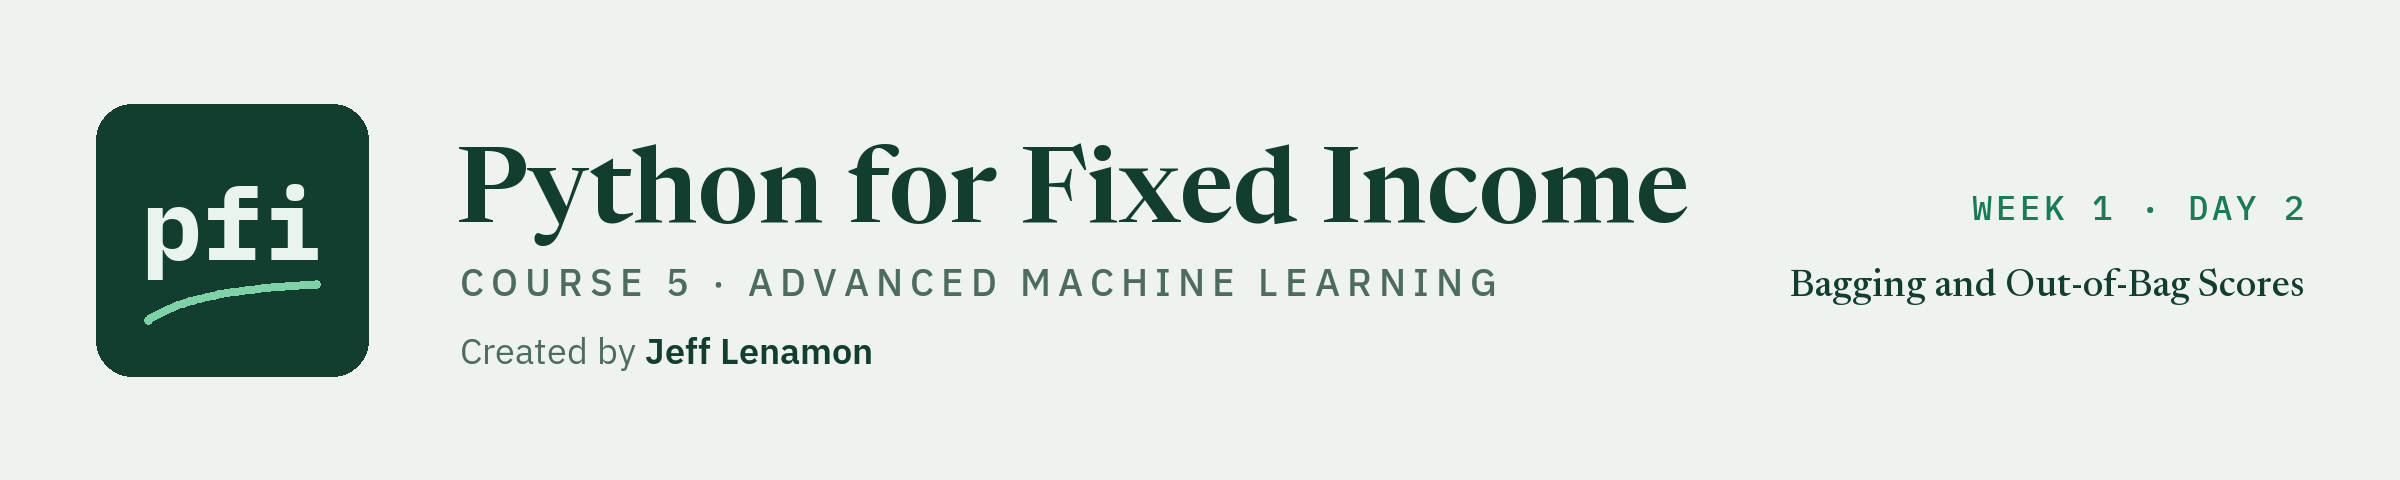

# Bagging and Out-of-Bag Scores

Week 1, Day 2. Day 1 averaged ten bootstrap trees by hand. Today: scikit-learn's bagging, how many trees are enough, and the out-of-bag rows, which score a bagged model for free, once you know what its ready-made score measures.

**Data:** `credit_card_default.csv`, 30,000 card accounts in Taiwan in 2005: **real**, UCI Machine Learning Repository dataset 350, CC BY 4.0. Citation: Yeh, I. (2009). Default of Credit Card Clients [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course5_advanced_ml/week1/day2/02_bagging_and_out_of_bag_scores.ipynb)

Day 1 ended with a finding: ten full trees, each fitted on its own bootstrap sample, are each weak and unstable, and their average ranks the validation accounts far better than any one of them. That procedure has a name, **bagging**: fit the same kind of model to many bootstrap samples of the training rows, and average what they give. Today you build it with scikit-learn, decide how many trees it needs, and use the rows each tree never saw to score the whole model without touching the validation rows.

**The card rules, as on every card day in this course.**

* **The data is real.** `credit_card_default.csv` holds 30,000 credit card accounts in Taiwan in 2005, with payment records from April to September and an outcome for the following month. Consumer credit there differs from US credit, and nothing here describes any other market.
* **People's attributes are never features.** `SEX`, `EDUCATION`, `MARRIAGE`, and `AGE` are not in any model, and no output is grouped by them. Every model today uses the other 19 columns, Course 4's.
* **Course 4's split, rebuilt.** 18,000 training rows fit, 6,000 validation rows report, and Course 4's 6,000 test rows stay closed for the whole course, by day 1's test-row rule (day 1, section 1.2).
* **A model's output is described, never acted on.** A bagged model's output is the model probability of default in this file (the average of its trees' outputs), or a flag at a threshold. No output of either kind is a credit decision for any person.

Today you will:

1. Rebuild day 1's average of ten trees: bagging by hand.
2. Fit `BaggingClassifier` and prove with `bagged_proba` that it is that average.
3. Measure how validation ROC AUC changes from 10 trees to 100.
4. Score the model on its out-of-bag rows with `oob_score=True`.
5. Find out what `oob_score_` measures, and compute the out-of-bag ROC AUC with `oob_auc`.
6. See where out-of-bag scoring helps most: few rows.
7. Bag a logistic regression, and see why almost nothing changes.
8. See what bagging cannot fix, for day 3.

Q. Set up today's work folder: the thread settings, the seed, the card file, and the modules as day 1 left them.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, scikit-learn, XGBoost, or LightGBM is imported: if you ran another
# cell first, restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import importlib.util
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("xgboost", "xgboost"), ("lightgbm", "lightgbm"), ("imblearn", "imbalanced-learn"), ("shap", "shap"), ("pytest", "pytest")]:
    if importlib.util.find_spec(module_name) is None:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.")

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course5_advanced_ml/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "scipy": "1.18.1", "xgboost": "3.4.1", "lightgbm": "4.7.0", "imbalanced-learn": "0.14.2", "shap": "0.52.0", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "credit_card_default.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course5_02_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["credit_card_default.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, scipy 1.18.1, xgboost 3.4.1, lightgbm 4.7.0, imbalanced-learn 0.14.2, shap 0.52.0, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course5_02__kzrmbnc, in your temp folder
Data files from the data folder of the course repo: credit_card_default.csv
SEED = 42


Q. Write `mlkit.py`, Course 4's complete module, unchanged. `ensemblekit` imports it.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")


def cluster_profile(frame: pd.DataFrame, labels: ArrayLike, columns: list[str]) -> pd.DataFrame:
    """Describe each cluster in the data's own units: how many rows, and the median of each column.

    Inputs: frame, the rows in their original units (oas in bp, duration in years), not the scaled features the
    clusters were fitted on; labels, the cluster of each row, in the same order; columns, the columns to profile.
    Output: a DataFrame indexed by cluster (named cluster, sorted), with count and one median column per name in
    columns, in the frame's units. A profile describes a group; it does not rank one.
    Excel: a pivot table counts and averages but has no median; =MEDIAN(IF(labels=k, column)) does.
    Raises ValueError if labels and frame differ in length, frame is empty, or a column is not in frame.
    """
    # check the inputs line up and the columns exist
    labels = np.asarray(labels)
    if len(frame) == 0:
        raise ValueError("frame is empty")
    if len(labels) != len(frame):
        raise ValueError(f"labels has {len(labels)} values and frame has {len(frame)} rows")
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"columns not in frame: {missing}")
    # group the original rows by cluster, then count and take medians
    grouped = frame[columns].groupby(pd.Series(labels, index=frame.index, name="cluster"))
    profile = grouped.median()
    profile.insert(0, "count", grouped.size())
    return profile.sort_index()


from sklearn.decomposition import PCA


def pca_loadings(pca: PCA, names: list[str]) -> pd.DataFrame:
    """The loadings of a fitted PCA, one column per component, each with a fixed sign.

    Inputs: pca, a fitted scikit-learn PCA; names, the input columns in the order the PCA saw them (for the
    curve, the tenors).
    Output: a DataFrame indexed by name with columns PC1, PC2, ...: each component's weights on the inputs
    (pca.components_ transposed, unit length). A component's sign is arbitrary, so each column is multiplied by
    -1 where needed to make its loadings sum to a positive number; a rerun or another library then gives the
    same picture. Scores that match these loadings are (X - pca.mean_) @ loadings.
    Excel: no PCA function; =MMULT(changes less their column means, loadings) gives the scores.
    Raises ValueError if names does not have one entry per input column.
    """
    # one name per input column
    components = np.asarray(pca.components_)
    if len(names) != components.shape[1]:
        raise ValueError(f"{len(names)} names for {components.shape[1]} input columns")
    loadings = pd.DataFrame(components.T, index=names,
                            columns=[f"PC{i}" for i in range(1, components.shape[0] + 1)])
    # flip each component whose loadings sum to a negative number
    signs = np.where(loadings.sum(axis=0) < 0, -1.0, 1.0)
    return loadings * signs


def explained_table(pca: PCA) -> pd.DataFrame:
    """The share of variance each component of a fitted PCA accounts for, and the running total, in percent.

    Input: pca, a fitted scikit-learn PCA.
    Output: a DataFrame indexed by PC1, PC2, ... with explained_pct (explained_variance_ratio_ x 100) and
    cumulative_pct (the running sum). With every component kept, the last cumulative_pct is 100.
    """
    # the ratios in percent, then their running sum
    explained = np.asarray(pca.explained_variance_ratio_) * 100
    index = [f"PC{i}" for i in range(1, len(explained) + 1)]
    return pd.DataFrame({"explained_pct": explained, "cumulative_pct": np.cumsum(explained)}, index=index)

Writing mlkit.py


Q. Write `ensemblekit.py` and `test_ensemblekit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [3]:
%%writefile ensemblekit.py
"""ensemblekit: the pieces of ensembles, tuning, and rare-event modelling that the libraries leave to the analyst,
written down and tested.

Written day by day in Python for Fixed Income, Course 5: Advanced Machine Learning. It imports mlkit (Course 4's
module) and never changes it.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- The positive class is 1 (default, bankrupt). A row is flagged when its model output is at least the threshold.
- Course 5 never scores a row that Course 4 used as a test row. The course4_*_rows functions rebuild Course 4's
  splits exactly and return only the rows Course 5 may use; the closed rows are never returned.
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart.
- Every library call that can use more than one thread is given n_jobs=1, so every run gives the same digits.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from sklearn.model_selection import train_test_split  # Course 4's split, rebuilt

import mlkit  # Course 4's module: thresholds, metrics, splitters, and the no-leak check

# the card file: its outcome column and the 19 model columns (the four person columns are never features)
CARD_TARGET = "default payment next month"
CARD_FEATURES = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
    [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]


def course4_card_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's 60/20/20 split of the card file, rebuilt, without its test rows.

    Input: frame, the 30,000 accounts of credit_card_default.csv as read by pd.read_csv.
    Output: X_train (18,000 rows), X_valid (6,000 rows), y_train, y_valid, with the 19 model columns in
    CARD_FEATURES and the file's row labels. Course 4's 6,000 test rows are never returned.
    Convention: the same two calls as Course 4: train_test_split(test_size=0.2, stratify=y, random_state=42), then
    the remaining 80 percent split with test_size=0.25, stratified, same seed. The validation rows were used in
    Course 4 to choose a threshold and a pruning level, never to fit.
    Raises ValueError if a column is missing or the frame does not have 30,000 rows.
    """
    # check the frame is the whole card file
    missing = [name for name in CARD_FEATURES + [CARD_TARGET] if name not in frame.columns]
    if missing:
        raise ValueError(f"frame lacks the columns {missing}")
    if len(frame) != 30_000:
        raise ValueError(f"frame must hold the 30,000 card accounts, not {len(frame)}")
    X, y = frame[CARD_FEATURES], frame[CARD_TARGET]
    # Course 4's first cut puts 20 percent aside as test rows: they are dropped here, never returned
    X_rest, _, y_rest, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    # Course 4's second cut: a quarter of the rest (20 percent of the file) as validation rows
    X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                          random_state=42)
    mlkit.assert_disjoint(X_train.index, X_valid.index)
    return X_train, X_valid, y_train, y_valid


def bootstrap_positions(n_rows: int, seed: int = 42) -> np.ndarray:
    """Draw n_rows row positions with replacement: one bootstrap sample.

    Input: n_rows, how many rows the data has (at least 1); seed, the random seed.
    Output: an array of n_rows positions from 0 to n_rows - 1, in the order drawn. A position can appear more than
    once, and some positions do not appear at all (about 36.8 percent of them for large n_rows).
    Convention: np.random.default_rng(seed).integers(0, n_rows, n_rows), so the same seed gives the same sample.
    Excel: =RANDBETWEEN(1,n) draws one position but takes no seed and changes at every recalculation.
    Raises ValueError if n_rows is below 1.
    """
    if n_rows < 1:
        raise ValueError(f"n_rows must be at least 1, not {n_rows}")
    # one generator per call, seeded, so the draw does not depend on anything drawn before
    rng = np.random.default_rng(seed)
    return rng.integers(0, n_rows, n_rows)


def out_of_bag(n_rows: int, drawn: np.ndarray) -> np.ndarray:
    """The positions a bootstrap sample never drew: its out-of-bag rows.

    Inputs: n_rows, how many rows the data has; drawn, the positions of a bootstrap sample.
    Output: the sorted positions from 0 to n_rows - 1 that are not in drawn.
    Convention: a model fitted on the drawn rows has never seen these rows, so they can score it.
    Raises ValueError if drawn is empty or holds a position outside 0 to n_rows - 1.
    """
    positions = np.asarray(drawn)
    if positions.size == 0:
        raise ValueError("drawn is empty")
    if positions.min() < 0 or positions.max() > n_rows - 1:
        raise ValueError(f"drawn holds a position outside 0 to {n_rows - 1}")
    # every position, minus the ones drawn at least once
    return np.setdiff1d(np.arange(n_rows), positions)

Writing ensemblekit.py


In [4]:
%%writefile test_ensemblekit.py
"""Tests for ensemblekit.py.

Expected values come from scikit-learn, XGBoost, LightGBM, imbalanced-learn, or SHAP on the same inputs, from
Course 4's published numbers, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from functools import cache
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import ensemblekit

HERE = Path(__file__).resolve().parent
SEED = 42


@cache
def read_card() -> pd.DataFrame:
    """The 30,000 UCI card accounts, read once per test run."""
    return pd.read_csv(HERE / "credit_card_default.csv")


@cache
def card_rows() -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's training and validation rows of the card file."""
    return ensemblekit.course4_card_rows(read_card())


def card_small(n: int = 3_000) -> tuple[pd.DataFrame, pd.Series]:
    """The first n of Course 4's training rows, for tests that fit many models and must stay fast."""
    X_train, _, y_train, _ = card_rows()
    return X_train.iloc[:n], y_train.iloc[:n]


def course4_card_test_labels() -> set:
    """The row labels of Course 4's card test set, recomputed with Course 4's own call."""
    card = read_card()
    y = card[ensemblekit.CARD_TARGET]
    _, X_test = train_test_split(card, test_size=0.2, stratify=y, random_state=SEED)
    return set(X_test.index)


def test_course4_card_rows_counts():
    X_train, X_valid, y_train, y_valid = card_rows()
    assert (len(X_train), len(X_valid), len(y_train), len(y_valid)) == (18_000, 6_000, 18_000, 6_000)
    assert list(X_train.columns) == ensemblekit.CARD_FEATURES
    for person in ("SEX", "EDUCATION", "MARRIAGE", "AGE", "ID"):
        assert person not in X_train.columns
    with pytest.raises(ValueError):
        ensemblekit.course4_card_rows(read_card().iloc[:100])


def test_course4_card_rows_closed_rows():
    X_train, X_valid, _, _ = card_rows()
    closed = course4_card_test_labels()
    assert len(closed) == 6_000
    assert not closed & set(X_train.index)
    assert not closed & set(X_valid.index)


def test_course4_card_rows_reproduces_logistic():
    X_train, X_valid, y_train, y_valid = card_rows()
    model = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
    model.fit(X_train, y_train)
    # Course 4 day 10's validation ROC AUC for the scaled logistic regression
    assert round(roc_auc_score(y_valid, model.predict_proba(X_valid)[:, 1]), 4) == 0.7190


def test_bootstrap_positions_with_replacement():
    drawn = ensemblekit.bootstrap_positions(1_000)
    assert drawn.shape == (1_000,)
    assert drawn.min() >= 0 and drawn.max() <= 999
    # with replacement: some rows twice, so fewer distinct positions than rows
    assert len(np.unique(drawn)) < 1_000
    with pytest.raises(ValueError):
        ensemblekit.bootstrap_positions(0)


def test_bootstrap_positions_seeded():
    first = ensemblekit.bootstrap_positions(500, seed=SEED)
    assert np.array_equal(first, ensemblekit.bootstrap_positions(500, seed=SEED))
    assert np.array_equal(first, np.random.default_rng(SEED).integers(0, 500, 500))
    assert not np.array_equal(first, ensemblekit.bootstrap_positions(500, seed=7))


def test_out_of_bag_hand():
    # rows 0 to 5; the sample drew 0, 0, 2, 5, 5, 5: rows 1, 3, 4 were never drawn
    left_out = ensemblekit.out_of_bag(6, np.array([0, 0, 2, 5, 5, 5]))
    assert left_out.tolist() == [1, 3, 4]
    with pytest.raises(ValueError):
        ensemblekit.out_of_bag(6, np.array([0, 6]))
    with pytest.raises(ValueError):
        ensemblekit.out_of_bag(6, np.array([], dtype=int))


def test_out_of_bag_share_near_e():
    n = 18_000
    drawn = ensemblekit.bootstrap_positions(n)
    left_out = ensemblekit.out_of_bag(n, drawn)
    # no row is both drawn and out of bag
    assert not set(left_out.tolist()) & set(drawn.tolist())
    # (1 - 1/n)^n tends to 1/e = 0.3679
    assert abs(len(left_out) / n - np.exp(-1)) < 0.01

Writing test_ensemblekit.py


Q. Import the modules.

In [5]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit
import ensemblekit

# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)
importlib.reload(ensemblekit)

# the functions and classes defined in ensemblekit itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(ensemblekit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "ensemblekit" and not name.startswith("_")]
print(f"ensemblekit functions: {functions}")

ensemblekit functions: ['course4_card_rows', 'bootstrap_positions', 'out_of_bag']


* The setup wrote Course 4's `mlkit.py` unchanged and `ensemblekit.py` with day 1's three functions; today adds two. Every call that can take `n_jobs` is written with `n_jobs=1`, as on day 1.

## 2.1 Bagging by Hand

Q. Load the card accounts, take Course 4's training and validation rows, and rebuild day 1's ten bootstrap trees and their average.

In [6]:
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier

# the 30,000 UCI card accounts (real data, CC BY 4.0; the citation is under the title)
card = pd.read_csv("credit_card_default.csv")
# Course 4's split, rebuilt: training and validation rows only, with the 19 model columns
X_train, X_valid, y_train, y_valid = ensemblekit.course4_card_rows(card)
assert not set(X_train.columns) & {"SEX", "EDUCATION", "MARRIAGE", "AGE"}, "a person column is in the features"
n_rows = len(X_train)

# day 1's recipe: ten bootstrap samples (seeds SEED to SEED + 9), one full tree on each
proba_ten = []
for k in range(10):
    drawn = ensemblekit.bootstrap_positions(n_rows, seed=SEED + k)
    tree = DecisionTreeClassifier(random_state=SEED).fit(X_train.iloc[drawn], y_train.iloc[drawn])
    proba_ten.append(tree.predict_proba(X_valid)[:, 1])
proba_ten = np.column_stack(proba_ten)

# bagging by hand: the average of the ten trees' outputs, account by account
proba_hand = proba_ten.mean(axis=1)
single = [roc_auc_score(y_valid, proba_ten[:, k]) for k in range(10)]
print(f"single trees: validation ROC AUC {min(single):.4f} to {max(single):.4f}")
print(f"average of the ten: validation ROC AUC {roc_auc_score(y_valid, proba_hand):.4f}, "
      f"average precision {average_precision_score(y_valid, proba_hand):.4f}")

single trees: validation ROC AUC 0.6015 to 0.6219
average of the ten: validation ROC AUC 0.7243, average precision 0.4453


**Rows.** Every model on the card file in this notebook is fitted on Course 4's 18,000 training rows (section 2.6 on the first 2,000 of them) and scored on Course 4's 6,000 validation rows, or on training rows it never saw (out of bag, or a held-out fold); Course 4's 6,000 test rows are never scored in this course.

* Day 1's numbers, rebuilt: single trees from 0.6015 to 0.6219, and their average at 0.7243. The average is the model probability of default in this file of a ten-tree model. That loop is all bagging is: bootstrap samples, one model on each, an average.

## 2.2 BaggingClassifier Is That Average

scikit-learn's `BaggingClassifier` runs the same loop. You give it the model to repeat (here a full tree), how many to fit (`n_estimators`), and a seed; it draws a bootstrap sample for each tree, fits it, and averages the trees' class-1 probabilities when you call `predict_proba`. Before trusting that description, test it: average the fitted trees yourself and compare.

Q. Add `bagged_proba` to `ensemblekit.py`. Read the docstring first.

In [7]:
%%writefile -a ensemblekit.py


from sklearn.metrics import roc_auc_score  # ranking quality from probabilities


def bagged_proba(bagging, X: pd.DataFrame) -> np.ndarray:
    """Bagging by hand: the average of each fitted tree's class-1 probability, each on its own columns.

    Inputs: bagging, a fitted BaggingClassifier; X, the rows to score, with the columns it was fitted on.
    Output: one number per row, the mean over bagging.estimators_ of each tree's class-1 probability on the
    columns listed in bagging.estimators_features_. It equals bagging.predict_proba(X)[:, 1] within 1e-12.
    Convention: a tree whose bootstrap sample held only one class gives 0 for class 1 when that class is 0.
    Excel: with each tree's column of outputs pasted side by side, =AVERAGE(B2:K2) filled down.
    Raises ValueError if bagging is not fitted.
    """
    if not hasattr(bagging, "estimators_"):
        raise ValueError("bagging is not fitted: call fit first")
    # the trees were fitted on plain arrays of the chosen columns, so score them the same way
    values = np.asarray(X, dtype=float)
    total = np.zeros(len(values))
    for tree, columns in zip(bagging.estimators_, bagging.estimators_features_):
        proba = tree.predict_proba(values[:, columns])
        # the tree's classes are positions in bagging.classes_; class 1 is position 1
        position = np.flatnonzero(tree.classes_ == 1)
        total += proba[:, position[0]] if position.size else 0.0
    return total / len(bagging.estimators_)

Appending to ensemblekit.py


* `estimators_` holds the fitted trees and `estimators_features_` the columns each one was fitted on. With the defaults every tree gets all the columns, but `BaggingClassifier` can also give each tree a random subset of columns (`max_features`), so the function always scores each tree on its own columns.
* The trees were fitted on plain arrays, so the function scores them on `np.asarray(X)`, not on the DataFrame.
* A tree whose bootstrap sample happened to hold no defaults knows only class 0; `position.size` is then 0 and the tree adds 0 for class 1, which is what scikit-learn does.

Q. Add its two tests: it equals scikit-learn's output, and it refuses a model that was never fitted.

In [8]:
%%writefile -a test_ensemblekit.py


from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier


def small_bagging(n_estimators: int = 10, oob: bool = False) -> tuple[BaggingClassifier, pd.DataFrame, pd.Series]:
    X, y = card_small()
    bagging = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=n_estimators,
                                oob_score=oob, random_state=SEED, n_jobs=1)
    return bagging.fit(X, y), X, y


def test_bagged_proba_matches_sklearn():
    bagging, X, _ = small_bagging()
    _, X_valid, _, _ = card_rows()
    assert ensemblekit.bagged_proba(bagging, X_valid) == pytest.approx(bagging.predict_proba(X_valid)[:, 1], abs=1e-12)
    # also with a random half of the columns per tree, so estimators_features_ matters
    X, y = card_small()
    half = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=10, max_features=0.5,
                             random_state=SEED, n_jobs=1).fit(X, y)
    assert ensemblekit.bagged_proba(half, X_valid) == pytest.approx(half.predict_proba(X_valid)[:, 1], abs=1e-12)


def test_bagged_proba_rejects_unfitted():
    with pytest.raises(ValueError, match="not fitted"):
        ensemblekit.bagged_proba(BaggingClassifier(random_state=SEED), card_small()[0])

Appending to test_ensemblekit.py


* `small_bagging` fits on `card_small()`, the first 3,000 training rows, so the tests stay fast. The first test also tries `max_features=0.5`, where each tree sees half the columns, so a function that ignored `estimators_features_` would fail it.

Q. Reload the module and run the tests.

In [9]:
importlib.reload(ensemblekit)
print(f"bagged_proba in ensemblekit: {hasattr(ensemblekit, 'bagged_proba')}")

bagged_proba in ensemblekit: True


In [10]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_ensemblekit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.........                                                                [100%]
9 passed in 33.71s



* `9 passed`: day 1's 7 and the two new ones.

Q. Fit `BaggingClassifier` with ten full trees on the training rows. Is its output the average of its trees?

In [11]:
from sklearn.ensemble import BaggingClassifier

# ten full trees, each on its own bootstrap sample of the training rows, drawn from SEED
bagging_10 = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=10, random_state=SEED, n_jobs=1)
bagging_10.fit(X_train, y_train)
proba_10 = bagging_10.predict_proba(X_valid)[:, 1]

# bagging by hand on the fitted trees, against scikit-learn's own output
by_hand = ensemblekit.bagged_proba(bagging_10, X_valid)
print(f"largest gap on {len(X_valid):,} validation accounts within 1e-12: {np.abs(by_hand - proba_10).max() < 1e-12}")
print(f"each tree's sample: {len(bagging_10.estimators_samples_[0]):,} rows drawn, "
      f"{min(len(np.unique(s)) for s in bagging_10.estimators_samples_):,} to "
      f"{max(len(np.unique(s)) for s in bagging_10.estimators_samples_):,} distinct")
print(f"bagging, 10 trees: validation ROC AUC {roc_auc_score(y_valid, proba_10):.4f}, "
      f"average precision {average_precision_score(y_valid, proba_10):.4f}")

largest gap on 6,000 validation accounts within 1e-12: True
each tree's sample: 18,000 rows drawn, 11,321 to 11,423 distinct
bagging, 10 trees: validation ROC AUC 0.7320, average precision 0.4584


* The hand average equals scikit-learn's output on every validation account, within 1e-12. **A bagged model's probability is the plain average of its trees' probabilities**, nothing more.
* Each tree saw 18,000 draws holding 11,321 to 11,423 distinct rows, about 63.2 percent, as day 1 found for one sample.
* Its validation ROC AUC, 0.7320, differs from the hand version's 0.7243 only because scikit-learn draws its own ten samples from the seed. Ten different trees, the same kind of result.

## 2.3 How Many Trees

More trees means more outputs in each average. Does the average keep improving?

Q. Fit bagging with 10, 25, 50, and 100 trees, and score each on the validation rows.

In [12]:
sizes = [10, 25, 50, 100]
curve = []
for n_trees in sizes:
    # the same seed each time, so each model's first trees are the smaller model's trees
    model = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=n_trees, random_state=SEED, n_jobs=1)
    model.fit(X_train, y_train)
    proba_valid = model.predict_proba(X_valid)[:, 1]
    curve.append({"trees": n_trees, "validation ROC AUC": roc_auc_score(y_valid, proba_valid),
                  "average precision": average_precision_score(y_valid, proba_valid)})
bagging_100, proba_100 = model, proba_valid   # the last model fitted is the 100-tree one
curve = pd.DataFrame(curve).set_index("trees")
print(curve.round(4).to_string())

       validation ROC AUC  average precision
trees                                       
10                 0.7320             0.4584
25                 0.7495             0.4876
50                 0.7594             0.5053
100                0.7602             0.5105


* Validation ROC AUC rises with every step, fast at first and then barely: 0.7320 at 10 trees, 0.7495 at 25, 0.7594 at 50, 0.7602 at 100. Going from 10 to 25 trees adds 0.0175; going from 50 to 100 adds 0.0008. Average precision follows the same path, to 0.5105.
* Here every step helped, and the steps shrank. Each added tree is one more noisy member in the average, so its share of the average falls as the count grows; the cost, run time, grows with the count. For this file, the curve flattens between 50 and 100 trees.
* At 100 trees bagging (0.7602) is above Course 4's logistic regression (0.7190) and 0.0025 below day 1's pruned tree (0.7627), with no pruning at all.

Q. Draw the curve.

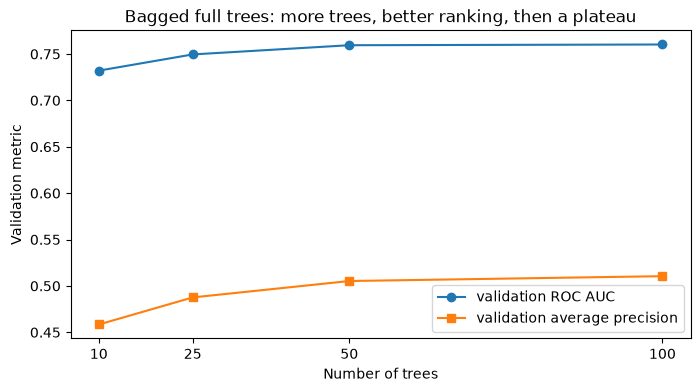

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(curve.index, curve["validation ROC AUC"], marker="o", label="validation ROC AUC")
ax.plot(curve.index, curve["average precision"], marker="s", label="validation average precision")
ax.set_xticks(curve.index)
ax.set_title("Bagged full trees: more trees, better ranking, then a plateau")
ax.set_xlabel("Number of trees")
ax.set_ylabel("Validation metric")
ax.legend()
plt.show()

* Both lines bend flat. The first trees remove most of the instability day 1 measured; later trees remove what little is left.

## 2.4 The Out-of-Bag Rows Score the Whole Model

Day 1 scored one tree on the rows its sample left out. A bagged model can do this for every row: each training row was left out by about 36.8 percent of the trees, so it can be scored by the average of **those trees only**, trees that never saw it. Every training row then has an honest output, and the training rows become a validation set that costs nothing. scikit-learn does this when you pass `oob_score=True`.

Q. Add `oob_auc` to `ensemblekit.py`, and its two tests.

In [14]:
%%writefile -a ensemblekit.py


def oob_auc(model, y_train) -> float:
    """ROC AUC of the out-of-bag probabilities of a bagged model or a random forest.

    Inputs: model, fitted with oob_score=True on the training rows; y_train, those rows' outcomes, in order.
    Output: roc_auc_score(y_train, model.oob_decision_function_[:, 1]): each row scored only by the trees that
    did not draw it.
    Convention: model.oob_score_ is the accuracy of the out-of-bag votes for a classifier, not ROC AUC; this
    function gives the ranking number the course compares models by.
    Raises ValueError if the model was fitted without oob_score=True, or if a row has no out-of-bag vote (too few
    trees, so some row was drawn by every tree).
    """
    if not hasattr(model, "oob_decision_function_"):
        raise ValueError("the model has no out-of-bag outputs: fit it with oob_score=True")
    proba = model.oob_decision_function_[:, 1]
    if np.isnan(proba).any():
        raise ValueError(f"{int(np.isnan(proba).sum())} rows have no out-of-bag vote: use more trees")
    return float(roc_auc_score(y_train, proba))

Appending to ensemblekit.py


In [15]:
%%writefile -a test_ensemblekit.py


def test_oob_auc_matches_roc_auc():
    bagging, _, y = small_bagging(n_estimators=40, oob=True)
    assert ensemblekit.oob_auc(bagging, y) == pytest.approx(roc_auc_score(y, bagging.oob_decision_function_[:, 1]),
                                                            abs=1e-12)
    # oob_score_ is accuracy, a different number
    assert ensemblekit.oob_auc(bagging, y) != pytest.approx(bagging.oob_score_, abs=1e-3)


def test_oob_auc_requires_oob_score():
    bagging, _, y = small_bagging()
    with pytest.raises(ValueError, match="oob_score=True"):
        ensemblekit.oob_auc(bagging, y)

Appending to test_ensemblekit.py


* `oob_decision_function_` holds each training row's out-of-bag output: for each class, the average probability from the trees that did not draw the row. `oob_auc` ranks the rows by its class-1 column.
* If a row was drawn by every tree, it has no out-of-bag output and its entry is NaN; the function stops rather than quietly scoring fewer rows. The convention line in the docstring is the subject of section 2.5.

Q. Reload the module and run all of today's tests.

In [16]:
importlib.reload(ensemblekit)
print(f"oob_auc in ensemblekit: {hasattr(ensemblekit, 'oob_auc')}")

oob_auc in ensemblekit: True


In [17]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_ensemblekit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

...........                                                              [100%]
11 passed in 9.36s



* `11 passed`: the module's five functions.

Q. Refit the 100-tree model with `oob_score=True`. Does that change the model, and how many trees score each training row?

In [18]:
# the same model as bagging_100, asked to score its own training rows out of bag
bagging_oob = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=100, oob_score=True,
                                random_state=SEED, n_jobs=1)
bagging_oob.fit(X_train, y_train)
print(f"same validation outputs as bagging_100: {np.array_equal(bagging_oob.predict_proba(X_valid)[:, 1], proba_100)}")

# for each training row, the number of trees whose sample left it out
votes = np.zeros(n_rows, dtype=int)
for drawn in bagging_oob.estimators_samples_:
    left_out = np.ones(n_rows, dtype=bool)
    left_out[drawn] = False
    votes += left_out
print(f"trees that never saw a row: {votes.mean():.1f} on average, from {votes.min()} to {votes.max()}")
print(pd.DataFrame(bagging_oob.oob_decision_function_[:3], columns=["no default", "default"]).round(4).to_string())

same validation outputs as bagging_100: True
trees that never saw a row: 36.8 on average, from 17 to 56
   no default  default
0      0.8000   0.2000
1      0.9737   0.0263
2      1.0000   0.0000


* `oob_score=True` changes nothing about the trees: the same seed draws the same samples, and the validation outputs are identical. It only adds the out-of-bag scoring.
* Each training row was left out by 36.8 of the 100 trees on average (17 to 56), about the 36.8 percent day 1 derived. The table shows the first three rows' out-of-bag outputs: each row's two numbers add up to 1, and the second is that row's out-of-bag model probability of default in this file.

## 2.5 The Out-of-Bag Score Is Accuracy

scikit-learn also gives a single number, `oob_score_`. Its name says "score"; what it measures has to be looked up.

Q. Print `oob_score_` beside the out-of-bag accuracy computed by hand, the all-zero baseline, and the out-of-bag ROC AUC.

In [19]:
oob_proba = bagging_oob.oob_decision_function_[:, 1]

# accuracy of the out-of-bag votes: flag a row when its out-of-bag probability is above 0.5
by_hand_accuracy = ((oob_proba > 0.5) == (y_train == 1)).mean()
print(f"oob_score_:                         {bagging_oob.oob_score_:.4f}")
print(f"out-of-bag accuracy, by hand:       {by_hand_accuracy:.4f}")
print(f"flag no account (all-zero baseline): {1 - y_train.mean():.4f}")
print(f"out-of-bag ROC AUC (oob_auc):       {ensemblekit.oob_auc(bagging_oob, y_train):.4f}")
print(f"validation ROC AUC of the same model: {roc_auc_score(y_valid, proba_100):.4f}")

oob_score_:                         0.8109
out-of-bag accuracy, by hand:       0.8109
flag no account (all-zero baseline): 0.7788
out-of-bag ROC AUC (oob_auc):       0.7502
validation ROC AUC of the same model: 0.7602


* **`oob_score_` is accuracy**: 0.8109, the share of training rows whose out-of-bag vote at 0.5 gives the right outcome. The hand computation gives the same number. It is not ROC AUC, and it is only 0.0322 above flagging no account at all (0.7788), because 22.1 percent of accounts default and accuracy rewards saying "no default". A reader who sees "out-of-bag score 0.81" next to "validation ROC AUC 0.7602" and compares them is comparing two different measures.
* The hand version flags a row when its probability is **above** 0.5. 107 training rows sit exactly at 0.5, half their out-of-bag trees for each class, and scikit-learn counts them as no default; flagging at 0.5 or above gives 0.8099 instead.
* The ranking number is `oob_auc`: 0.7502. It is below the same model's validation ROC AUC (0.7602), and that is expected: each row's out-of-bag output averages only about 37 trees, not 100, and section 2.3 showed fewer trees rank worse. The 25-tree model's validation ROC AUC was 0.7495, close to this out-of-bag number. **An out-of-bag ROC AUC describes a smaller forest than the one you fitted**, so it leans low.

## 2.6 Where Out-of-Bag Helps: Few Rows

With 18,000 training rows and 6,000 validation rows, the card file has rows to spare. Many credit files do not. Cross-validation, Course 4's tool when rows are few, fits the model five times. The out-of-bag rows give a score from one fit.

Q. Take only the first 2,000 training rows. Score a 100-tree bagged model on them out of bag, and again by five-fold cross-validation.

In [20]:
from sklearn.model_selection import cross_val_score

# a small file: the first 2,000 training rows only
X_small, y_small = X_train.iloc[:2000], y_train.iloc[:2000]

# one fit, scored out of bag
small_oob = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=100, oob_score=True,
                              random_state=SEED, n_jobs=1).fit(X_small, y_small)
# five fits, each scored on the fifth of the rows it did not see (Course 4's folds)
folds = cross_val_score(BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=100, random_state=SEED,
                                          n_jobs=1), X_small, y_small, cv=mlkit.cv_folds(), scoring="roc_auc", n_jobs=1)

print(f"{len(X_small):,} rows, {y_small.sum()} defaults")
print(f"out-of-bag ROC AUC, one fit:          {ensemblekit.oob_auc(small_oob, y_small):.4f}")
print(f"five-fold ROC AUC, five fits:         mean {folds.mean():.4f}, fold sd {folds.std():.4f}, "
      f"folds from {folds.min():.4f} to {folds.max():.4f}")
print(f"the one-fit model on the validation rows: {roc_auc_score(y_valid, small_oob.predict_proba(X_valid)[:, 1]):.4f}")

2,000 rows, 415 defaults
out-of-bag ROC AUC, one fit:          0.7325
five-fold ROC AUC, five fits:         mean 0.7325, fold sd 0.0225, folds from 0.6994 to 0.7630
the one-fit model on the validation rows: 0.7366


* On 2,000 rows (415 defaults) the out-of-bag ROC AUC is 0.7325, and the mean of five folds is 0.7325: within 0.0000 of each other, from one fit against five. The five folds alone run from 0.6994 to 0.7630 (fold standard deviation 0.0225), so any one held-out fifth of a small file is a noisy score; the out-of-bag score uses every row once.
* The same model on the 6,000 validation rows gives 0.7366, a little above both, as section 2.5 leads you to expect.
* On a bagged model or a random forest, the out-of-bag score is a fair substitute for cross-validation when rows are few, as long as you read it as ROC AUC from `oob_auc`, not as `oob_score_`.

## 2.7 Bagging a Logistic Regression

Bagging accepts any model. Does it help a model that is already stable?

Q. Bag 25 copies of Course 4's scaled logistic regression and compare it with the single model.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Course 4's logistic regression, scaled inside a pipeline; and 25 copies of it, each on its own bootstrap sample
logistic = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]).fit(X_train, y_train)
bagged_logistic = BaggingClassifier(Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]),
                                    n_estimators=25, random_state=SEED, n_jobs=1).fit(X_train, y_train)
proba_log = logistic.predict_proba(X_valid)[:, 1]
proba_blog = bagged_logistic.predict_proba(X_valid)[:, 1]
for name, proba_valid in [("logistic regression", proba_log), ("bagged logistic, 25", proba_blog)]:
    print(f"{name}: validation ROC AUC {roc_auc_score(y_valid, proba_valid):.4f}, "
          f"average precision {average_precision_score(y_valid, proba_valid):.4f}")

# how far apart the members are on one account, for the logistic bag and the 100-tree bag
members_log = np.column_stack([m.predict_proba(X_valid.to_numpy()[:, f])[:, 1]
                               for m, f in zip(bagged_logistic.estimators_, bagged_logistic.estimators_features_)])
members_tree = np.column_stack([m.predict_proba(X_valid.to_numpy()[:, f])[:, 1]
                                for m, f in zip(bagging_100.estimators_, bagging_100.estimators_features_)])
print(f"average spread of the members on one account: logistic {members_log.std(axis=1).mean():.4f}, "
      f"full trees {members_tree.std(axis=1).mean():.4f}")

logistic regression: validation ROC AUC 0.7190, average precision 0.4946
bagged logistic, 25: validation ROC AUC 0.7195, average precision 0.4952


average spread of the members on one account: logistic 0.0121, full trees 0.3365


* Almost no change: 0.7190 alone, 0.7195 bagged. Bagging moved each account's output by 0.0020 on average and by at most 0.0454.
* The reason is in the last line. Twenty-five logistic regressions fitted on different bootstrap samples barely disagree: their average spread on an account is 0.0121, against 0.3365 for the full trees. A straight-line model fitted to 18,000 rows lands in nearly the same place whichever rows it sees, so there is little noise to average away. **Bagging helps unstable models.** A full tree is the textbook case; a logistic regression on this many rows is not.

## 2.8 What Bagging Cannot Fix

Averaging cancels what the trees do not share. What do the 100 trees share?

Q. Which question does each of the 100 trees ask first, and how alike are their outputs?

In [22]:
# each tree's first question, counted
first = pd.Series([f"{X_train.columns[f[t.tree_.feature[0]]]} <= {t.tree_.threshold[0]}"
                   for t, f in zip(bagging_100.estimators_, bagging_100.estimators_features_)], name="trees")
print(first.value_counts().to_string())

# correlation of every pair of trees' outputs on the validation accounts, averaged over the pairs
pairs = np.corrcoef(members_tree.T)[np.triu_indices(members_tree.shape[1], k=1)]
print(f"average correlation between two trees' outputs: {pairs.mean():.4f} over {len(pairs):,} pairs")

trees
PAY_0 <= 1.5    99
PAY_0 <= 0.5     1
average correlation between two trees' outputs: 0.2581 over 4,950 pairs


* All 100 trees ask about `PAY_0` first, 99 of them the same question, `PAY_0 <= 1.5`. With every column available at every split, the strongest column wins the first split in nearly every bootstrap sample, so the trees share their top and differ only below it.
* Two trees' outputs correlate at 0.2581 on average. That shared part is the same in every tree, so averaging more trees cannot remove it: it is why the curve in section 2.3 flattened. To gain more, the trees must disagree more.
* Day 3's random forest does that by letting each split look at only a random handful of columns, so `PAY_0` is not always on offer, and measures the correlation with a function of its own.

## Excel Side by Side

Excel has no worksheet function for bagging, and none for a decision tree. What it can do is check what a bagged model's numbers are made of, once the trees' outputs are pasted onto a sheet. Every formula below was typed into Excel by script (Excel 16.0 build 20430, 2026-10-05).

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| The bagged output on an account | `bagging_10.predict_proba(X_valid)[:, 1]` | `=AVERAGE(B2:K2)`, filled down, with the ten trees' validation outputs in B2:K6001 | equal to scikit-learn on all 6,000 accounts |
| The out-of-bag score | `bagging_oob.oob_score_` | `=SUMPRODUCT(--((B2:B18001>0.5)=(A2:A18001=1)))/ROWS(A2:A18001)` | 0.8109 |
| The same, flagging at 0.5 or above | `((oob_proba >= 0.5) == (y_train == 1)).mean()` | `=SUMPRODUCT(--((B2:B18001>=0.5)=(A2:A18001=1)))/ROWS(A2:A18001)` | 0.8099 |
| Rows exactly at 0.5 | `(oob_proba == 0.5).sum()` | `=COUNTIF(B2:B18001,0.5)` | 107 |
| Flag no account (baseline) | `1 - y_train.mean()` | `=1-AVERAGE(A2:A18001)` | 0.7788 |
| Out-of-bag ROC AUC | `ensemblekit.oob_auc(bagging_oob, y_train)` | thresholds `=SORT(UNIQUE(B2:B18001),,-1)` in M3, rates `=MAP(M3#,LAMBDA(t,SUM((A2:A18001=0)*(B2:B18001>=t))))/COUNTIF(A2:A18001,0)` and the same for defaults, then the trapezoid `=SUMPRODUCT((N3:Nk-N2:Nk-1),(O3:Ok+O2:Ok-1)/2)` | 0.7502 |

**The average.** Paste each of the ten trees' validation outputs into its own column, B to K, one row per account. In L2 type `=AVERAGE(B2:K2)` and fill it down: that column is the bagged model's output, the same job as `predict_proba` on `BaggingClassifier`, and it matched on every account.

**The out-of-bag score.** Paste `y_train` into column A and the out-of-bag probabilities into column B. `(B2:B18001>0.5)=(A2:A18001=1)` is TRUE where the vote at 0.5 gives the right outcome; `--` turns TRUE and FALSE into 1 and 0, `SUMPRODUCT` adds them, and dividing by `ROWS` gives the share. That is `oob_score_` exactly: an accuracy. With `>=0.5` the 107 rows at exactly 0.5 count as defaults and the share changes, which is how you find out which way scikit-learn breaks the tie. `=1-AVERAGE(A2:A18001)` is the accuracy of flagging nobody.

**The out-of-bag ROC AUC** is Course 4 day 8's trapezoid on column B: every distinct value as a threshold, highest first, the share of non-defaults and of defaults at or above each (`MAP` with `LAMBDA` compares the numbers directly; `COUNTIFS` with `">="&t` gave the same), a (0, 0) row on top, and `SUMPRODUCT` of the steps. It agrees with `oob_auc` within 1e-6, not 1e-12. A few out-of-bag values are the same fraction reached by two routes, reached by two different sums, and differ only in the last binary digit. Excel's `=` and `>=` treated 10 of those 11 pairs as equal (tested), so its curve has a few fewer steps.

Q. Do Excel's numbers equal Python's?

In [23]:
# Excel's numbers, from the course's Excel check, beside Python's for the same models and rows
excel = {"bagged output, first validation account": 0.4,
         "out-of-bag score (accuracy)": 0.8109444444444445,
         "all-zero baseline, training rows": 0.7787777777777778,
         "out-of-bag ROC AUC": 0.7501866098255389}
python = {"bagged output, first validation account": proba_10[0],
          "out-of-bag score (accuracy)": bagging_oob.oob_score_,
          "all-zero baseline, training rows": 1 - y_train.mean(),
          "out-of-bag ROC AUC": ensemblekit.oob_auc(bagging_oob, y_train)}

side_by_side = pd.DataFrame({"Excel": excel, "Python": python})
# exact for the first three; the ROC AUC within 1e-6 (the near-equal pairs in the notes above)
side_by_side["tolerance"] = [1e-12, 1e-12, 1e-12, 1e-6]
side_by_side["within tolerance"] = (side_by_side["Excel"] - side_by_side["Python"]).abs() < side_by_side["tolerance"]
print(side_by_side.to_string(formatters={"Excel": "{:.7f}".format, "Python": "{:.7f}".format, "tolerance": "{:.0e}".format}))

                                            Excel    Python tolerance  within tolerance
bagged output, first validation account 0.4000000 0.4000000     1e-12              True
out-of-bag score (accuracy)             0.8109444 0.8109444     1e-12              True
all-zero baseline, training rows        0.7787778 0.7787778     1e-12              True
out-of-bag ROC AUC                      0.7501866 0.7501857     1e-06              True


* The average, the accuracy, and the baseline match within 1e-12; the trapezoid ROC AUC matches within 1e-6, for the reason above. Excel can reproduce what a bagged model reports, once Python has fitted the trees.

## Save the Day with Git

Each day's work folder starts fresh, so the first commit holds Course 4's `mlkit.py` and the module as it stands at the end of today.

Q. Make the work folder a repository.

In [24]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [25]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course5_02__kzrmbnc and nowhere else


Q. Ignore the caches and workbooks, then commit `.gitignore`, `mlkit.py`, and today's two files.

In [26]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx

Writing .gitignore


In [27]:
!git -C "{work}" add .gitignore mlkit.py ensemblekit.py test_ensemblekit.py
!git -C "{work}" commit -q -m "ensemblekit day 2: bagged_proba and oob_auc, 11 tests"
!git -C "{work}" log --oneline

1a30e3e ensemblekit day 2: bagged_proba and oob_auc, 11 tests


Q. Start the experiment log with the 10-tree model, and commit it.

In [28]:
def log_row(name, output):
    """One experiment-log row: the model, the rows scored, its ranking metrics, and its flags at 0.5."""
    metrics = mlkit.classification_metrics(y_valid, (output >= 0.5).astype(int))
    return {"model": name, "rows": "validation", "roc_auc": roc_auc_score(y_valid, output),
            "average_precision": average_precision_score(y_valid, output), "threshold": 0.5, **metrics}


results = pd.DataFrame([log_row("bagging_10_trees", proba_10)])
# 4 decimals and LF line endings, so the diff below shows only real changes
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))

model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
bagging_10_trees,validation,0.7320,0.4584,0.5000,0.7943,0.5471,0.4069,0.4667



In [29]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: validation metrics of bagging with 10 trees"

Q. Add the 100-tree model and the bagged logistic regression to the log. What does Git say changed?

In [30]:
results = pd.concat([results, pd.DataFrame([log_row("bagging_100_trees", proba_100),
                                            log_row("bagged_logistic_25", proba_blog)])], ignore_index=True)
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print(f"accuracy of flagging no account (all-zero baseline) on the validation rows: {1 - y_valid.mean():.4f}")

accuracy of flagging no account (all-zero baseline) on the validation rows: 0.7788


In [31]:
# lines starting with + are new; the 10-tree line is unchanged, so it is not marked
!git -C "{work}" diff results.csv

diff --git a/results.csv b/results.csv
index e37244b..082c1e7 100644
--- a/results.csv
+++ b/results.csv
@@ -1,2 +1,4 @@
 model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
 bagging_10_trees,validation,0.7320,0.4584,0.5000,0.7943,0.5471,0.4069,0.4667
+bagging_100_trees,validation,0.7602,0.5105,0.5000,0.8143,0.6357,0.3760,0.4725
+bagged_logistic_25,validation,0.7195,0.4952,0.5000,0.8117,0.7223,0.2411,0.3616


* `git diff` shows the two new rows with a `+` and leaves the first row unmarked, because its 4-decimal text did not change. Writing the log with fixed decimals and LF endings is what makes a diff this clean.
* At threshold 0.5 the 100-tree model's validation accuracy is 0.8143 against the all-zero baseline of 0.7788; the threshold column stays 0.5 until day 5 brings out-of-fold thresholds. Accuracy is logged, never used to choose.

In [32]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: bagging with 100 trees and a bagged logistic regression"
!git -C "{work}" log --oneline

80ad8c6 Experiment log: bagging with 100 trees and a bagged logistic regression
14b895f Experiment log: validation metrics of bagging with 10 trees
1a30e3e ensemblekit day 2: bagged_proba and oob_auc, 11 tests


## Bring It Home

Add today's two functions to your own module in `my_bondmath`. Open a PowerShell terminal in VS Code.

**Step 1.** Go to your folder and open the two files.

```powershell
Set-Location "$HOME\projects\my_bondmath"
.\.venv\Scripts\Activate.ps1
code ensemblekit.py
code test_ensemblekit.py
```

If your venv lives in the course repo instead, activate that one, as on day 1.

**Step 2.** Paste the code of the two `%%writefile -a ensemblekit.py` cells (sections 2.2 and 2.4), without their first lines, at the end of `ensemblekit.py`; do the same for the two `test_ensemblekit.py` cells. Save both. The new test helpers read the card file that day 1 copied into the folder.

**Step 3.** Run the tests.

```powershell
python -m pytest -q test_ensemblekit.py
```

The last line says `11 passed`.

**Step 4.** Read the change, then commit the code only.

```powershell
git diff --stat
git add ensemblekit.py test_ensemblekit.py
git commit -m "ensemblekit day 2: bagged_proba and oob_auc, 11 tests"
git log --oneline -3
```

**In Colab**, download `ensemblekit.py` and `test_ensemblekit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Say what bagging is, build it by hand, and prove with `bagged_proba` that `BaggingClassifier` is the average of its trees.
* Choose a number of trees from a curve, and say why more trees stop helping.
* Score a bagged model on its out-of-bag rows, and say what `oob_score_` measures: accuracy, not ROC AUC.
* Compute the out-of-bag ROC AUC with `oob_auc`, and say why it leans low.
* Use an out-of-bag score in place of cross-validation when rows are few.
* Say why bagging helps a full tree and barely touches a logistic regression.
* Read `git diff` on the experiment log.

Tomorrow, day 3: random forests, which make the trees disagree on purpose.

## Exercises

The exercises use Course 4's card rows: fitted on the 18,000 training rows, scored on the 6,000 validation rows or out of bag, the test rows closed. The four person columns are not features, and every answer describes this file. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the card rows, fits a 25-tree bagged model with `oob_score=True` (exercises 2 and 4 use it), and defines `check`, a small function that marks your answers.

In [33]:
import warnings

from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier

# Course 4's training and validation rows of the card file
card = pd.read_csv("credit_card_default.csv")
X_train, X_valid, y_train, y_valid = ensemblekit.course4_card_rows(card)

# 25 full trees, scored out of bag
bagging_oob_25 = BaggingClassifier(DecisionTreeClassifier(random_state=SEED), n_estimators=25, oob_score=True,
                                   random_state=SEED, n_jobs=1).fit(X_train, y_train)


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Bagging can give each tree a smaller sample. Fit 100 full trees with `max_samples=0.5` (each tree draws 9,000 rows with replacement) and `oob_score=True`, `random_state=SEED`, `n_jobs=1`. Store its validation ROC AUC in **ex1_valid_auc** and its out-of-bag ROC AUC (`ensemblekit.oob_auc`) in **ex1_oob_auc**.

In [34]:
ex1_valid_auc = ...
ex1_oob_auc = ...

In [35]:
check("Exercise 1 validation ROC AUC", ex1_valid_auc, 0.7673487370165574)
check("Exercise 1 out-of-bag ROC AUC", ex1_oob_auc, 0.7570185556075244)

Exercise 1 validation ROC AUC: not attempted yet
Exercise 1 out-of-bag ROC AUC: not attempted yet


### Exercise 2

Q. How far below the validation ROC AUC does the out-of-bag ROC AUC sit, at 25 trees and at 100? Use `bagging_oob_25` from the first cell, and fit the 100-tree model with `oob_score=True` yourself. Store validation ROC AUC minus out-of-bag ROC AUC in **ex2_gap_25** and **ex2_gap_100**.

In [36]:
ex2_gap_25 = ...
ex2_gap_100 = ...

In [37]:
check("Exercise 2 the gap at 25 trees", ex2_gap_25, 0.025864290435551274)
check("Exercise 2 the gap at 100 trees", ex2_gap_100, 0.010026065813696361)

Exercise 2 the gap at 25 trees: not attempted yet
Exercise 2 the gap at 100 trees: not attempted yet


### Exercise 3

Q. Add a function to your module. `oob_coverage(model)` returns the share of training rows with at least one out-of-bag vote (rows with none have NaN in `oob_decision_function_`); it raises `ValueError` for a model without out-of-bag outputs. Write the docstring first. Then add `test_oob_coverage_hand`, which uses a small stand-in object with an `oob_decision_function_` of four rows, two of them NaN, and expects 0.5, and checks the `ValueError`. Run pytest and reload the module.

Then fit 10 full trees with `oob_score=True` (`random_state=SEED`, `n_jobs=1`) inside `with warnings.catch_warnings(record=True):` with `warnings.simplefilter("always")` as its first line, because scikit-learn warns when some rows have no out-of-bag vote, and store `ensemblekit.oob_coverage` of it in **ex3_coverage**.

Write the function in the cell that starts with `%%writefile -a ensemblekit.py` and the test in the one that starts with `%%writefile -a test_ensemblekit.py`, and run each of those cells once.

In [38]:
%%writefile -a ensemblekit.py


# Exercise 3: write oob_coverage(model) below this line

Appending to ensemblekit.py


In [39]:
%%writefile -a test_ensemblekit.py


# Exercise 3: write test_oob_coverage_hand() below this line

Appending to test_ensemblekit.py


In [40]:
# run pytest, reload the module, fit the ten-tree model inside catch_warnings, then call your function
ex3_coverage = ...

In [41]:
check("Exercise 3 coverage of ten trees", ex3_coverage, 0.9896666666666667)

Exercise 3 coverage of ten trees: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that reports a bagged model's out-of-bag ROC AUC, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Report how well a bagged model ranks its own training rows, scored out of bag.

    model: a BaggingClassifier or random forest fitted with oob_score=True; y_train: its training outcomes.
    Returns {"oob_roc_auc": ...}: the ROC AUC of the out-of-bag class-1 probabilities against y_train, each row
    scored only by the trees that did not draw it.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns a number between 0 and 1, and contains one bug.

In [42]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def oob_report(model, y_train):
    """Report how well a bagged model ranks its own training rows, scored out of bag.

    model: a BaggingClassifier or random forest fitted with oob_score=True; y_train: its training outcomes.
    Returns {"oob_roc_auc": ...}: the ROC AUC of the out-of-bag class-1 probabilities against y_train, each row
    scored only by the trees that did not draw it.
    """
    # scikit-learn already scores the out-of-bag rows, so reuse its number
    return {"oob_roc_auc": model.oob_score_}

Q. Before you run the next cell: section 2.5 found an out-of-bag ROC AUC of 0.7502 for 100 trees. Will `oob_report` give the 25-tree model a number above or below that?

In [43]:
report = oob_report(bagging_oob_25, y_train)
print(f"reported out-of-bag ROC AUC: {report['oob_roc_auc']:.4f}")

reported out-of-bag ROC AUC: 0.8023


Q. Test the function against its docstring before you trust it.

In [44]:
# the test, written from the docstring before the code is trusted
report = oob_report(bagging_oob_25, y_train)

# the number must be the out-of-bag ROC AUC, computed by the module's tested function
assert abs(report["oob_roc_auc"] - ensemblekit.oob_auc(bagging_oob_25, y_train)) < 1e-12, \
    "oob_roc_auc is not the out-of-bag ROC AUC"
print(f"oob_report: {report['oob_roc_auc']:.4f}")

AssertionError: oob_roc_auc is not the out-of-bag ROC AUC

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store `oob_report(bagging_oob_25, y_train)["oob_roc_auc"]` from the fixed function in **ex4_oob_roc_auc**.

In [45]:
# fix the function above and run the test again, then store the answer
ex4_oob_roc_auc = ...

In [46]:
check("Exercise 4 the fixed out-of-bag ROC AUC", ex4_oob_roc_auc, 0.7236437380969393)

Exercise 4 the fixed out-of-bag ROC AUC: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```